# Stock Price Analysis


#  JPM Stock Analysis and Forecasting

##  Objective
To analyze JPMorgan stock price data and predict future trends using time series forecasting.

##  Problem Statement
Stock prices fluctuate daily. This project analyzes historical data and predicts future prices using Prophet.

##  Dataset Description
Dataset contains:
- Date
- Open, High, Low, Close prices (in USD)
- Volume

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
# 1. DATA LOADING & CLEANING

df = pd.read_csv('JP M.csv')

# Remove '$' and ',' from price columns and convert to float

price_cols = ['Close', 'Open', 'High', 'Low']
for col in price_cols:
    df[col] = df[col].astype(str).str.replace('[\$,]', '', regex=True).astype(float)

# Convert Date to datetime and sort chronologically

df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date').reset_index(drop=True)

<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Dell\AppData\Local\Temp\ipykernel_348\303146249.py:9: SyntaxWarning: invalid escape sequence '\$'
  df[col] = df[col].astype(str).str.replace('[\$,]', '', regex=True).astype(float)


In [19]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Remove $ sign and convert to float
cols = ['Close', 'Open', 'High', 'Low']

for col in cols:
    df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)

# Sort by date
df = df.sort_values('Date')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2514 non-null   datetime64[ns]
 1   Close   2514 non-null   float64       
 2   Volume  2514 non-null   int64         
 3   Open    2514 non-null   float64       
 4   High    2514 non-null   float64       
 5   Low     2514 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 118.0 KB


<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Dell\AppData\Local\Temp\ipykernel_348\108204042.py:8: SyntaxWarning: invalid escape sequence '\$'
  df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)


In [9]:
df.describe()

,Date,Close,Volume,Open,High,Low
count,2514,2514.000000,2.514000e+03,2514.000000,2514.000000,2514.000000
mean,2021-03-27 13:34:30.644391424,145.915036,1.303900e+07,145.862260,147.272327,144.496886
min,2016-03-31 00:00:00,57.320000,3.220496e+06,57.710000,58.430000,57.050000
25%,2018-09-26 06:00:00,103.315000,8.910389e+06,103.267500,104.462500,102.122500
50%,2021-03-27 12:00:00,127.385000,1.159212e+07,127.435000,128.945000,126.310000
75%,2023-09-25 18:00:00,163.757500,1.505524e+07,164.052500,165.165000,162.362500
max,2026-03-30 00:00:00,334.610000,5.616398e+07,332.620000,337.250000,330.650000
std,NaN,64.221907,6.323422e+06,64.175545,64.815965,63.568755


In [10]:
df.isnull().sum()

Date      0
Close     0
Volume    0
Open      0
High      0
Low       0
dtype: int64

## Last one-year stock price analysis

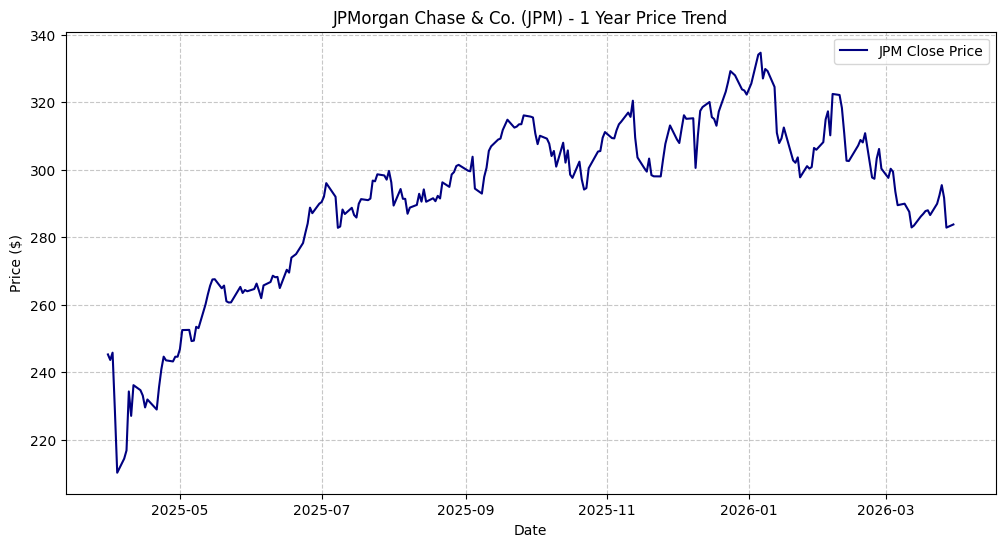

In [ ]:
# STOCK PRICE ANALYSIS [Requirement C.1]
latest_date = df['Date'].max()
one_year_ago = latest_date - pd.DateOffset(years=1)
df_recent = df[df['Date'] >= one_year_ago]

plt.figure(figsize=(12, 6))
plt.plot(df_recent['Date'], df_recent['Close'], color='navy', label='JPM Close Price')
plt.title('JPMorgan Chase & Co. (JPM) - 1 Year Price Trend')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Volatility and return analysis

In [26]:
# VOLATILITY AND RETURN ANALYSIS

# Calculate daily returns
df['JPM_Return'] = df['Close'].pct_change()

# Drop missing return row
returns = df['JPM_Return'].dropna()

# Calculate return statistics
average_daily_return = returns.mean()
daily_volatility = returns.std()
annualized_volatility = daily_volatility * np.sqrt(252)

print(f'Average Daily Return: {average_daily_return:.6f}')
print(f'Daily Volatility: {daily_volatility:.6f}')
print(f'Annualized Volatility: {annualized_volatility:.6f}')

Average Daily Return: 0.000772
Daily Volatility: 0.017266
Annualized Volatility: 0.274089


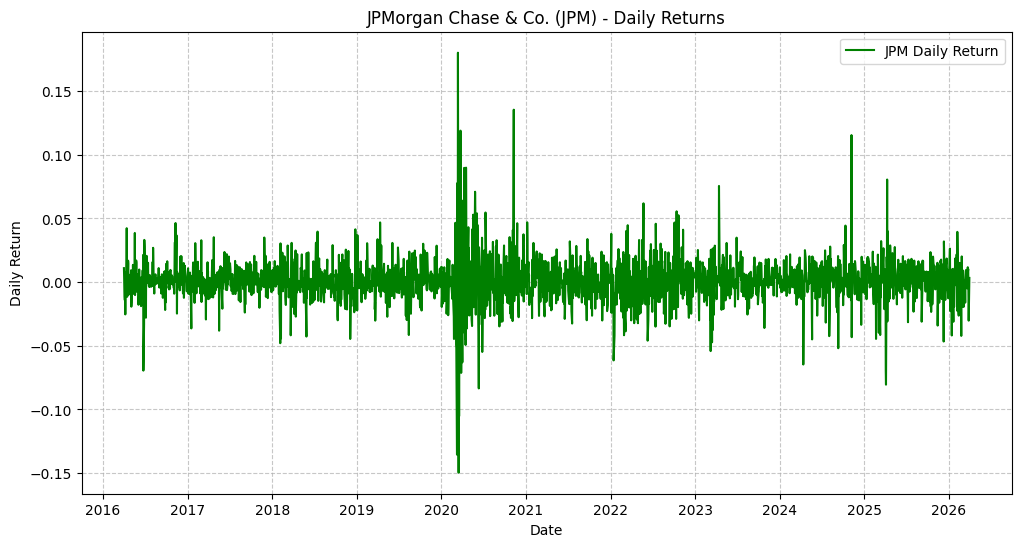

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['JPM_Return'], color='green', label='JPM Daily Return')
plt.title('JPMorgan Chase & Co. (JPM) - Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

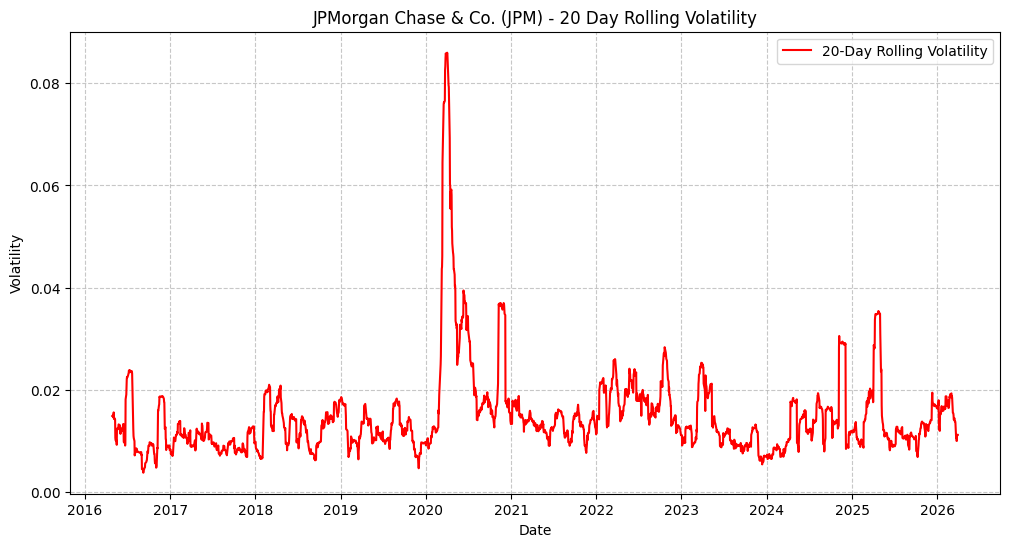

In [23]:
df['Rolling_20D_Volatility'] = df['JPM_Return'].rolling(window=20).std()

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Rolling_20D_Volatility'], color='red', label='20-Day Rolling Volatility')
plt.title('JPMorgan Chase & Co. (JPM) - 20 Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

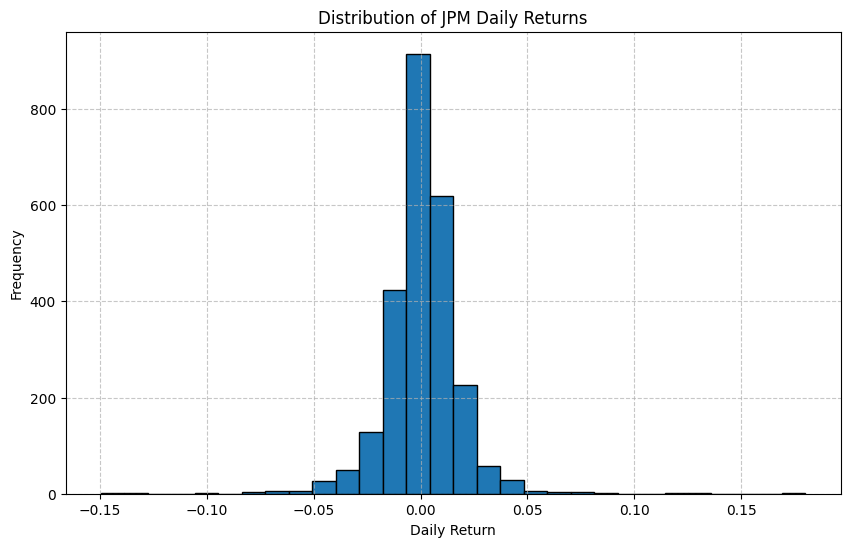

In [24]:
plt.figure(figsize=(10, 6))
plt.hist(returns, bins=30, edgecolor='black')
plt.title('Distribution of JPM Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Interpretation:
The daily return measures the percentage change in JPM stock price from one day to the next.  
The average daily return shows the stock’s typical daily performance, while daily volatility measures how much the returns fluctuate.  
Annualized volatility gives an estimate of the stock’s yearly risk level.  
The 20-day rolling volatility helps show how the stock’s risk changes over time.

#  Monte Carlo Simulation 
### Perform 100 simulations 
### Forecast stock price 30 days ahead 
### Present graphical output 
### Interpret mean forecast and risk range 

In [ ]:

# Calculate daily returns for volatility analysis
df['Returns'] = df['Close'].pct_change()
last_price = df['Close'].iloc[-1]
mu = df['Returns'].mean()
sigma = df['Returns'].std()

days = 30
simulations = 100
sim_results = np.zeros((days, simulations))

for i in range(simulations):
    prices = [last_price]
    for _ in range(days - 1):
        prices.append(prices[-1] * (1 + np.random.normal(mu, sigma)))
    sim_results[:, i] = prices

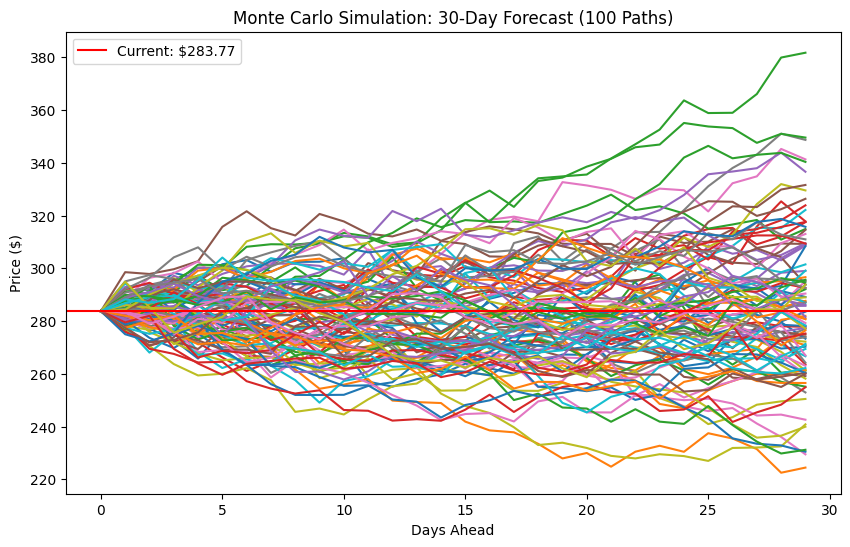

--- Technical Analysis Summary ---
Current Market Price: $283.77
Mean Forecast (30 days): $285.76
Forecast Range (Risk): $224.45 to $381.76


In [29]:
# Plotting the 100 simulations
plt.figure(figsize=(10, 6))
plt.plot(sim_results)
plt.axhline(y=last_price, color='red', linestyle='-', label=f'Current: ${last_price:.2f}')
plt.title(f'Monte Carlo Simulation: 30-Day Forecast (100 Paths)')
plt.xlabel('Days Ahead')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

# Output key statistics for your written report
print(f"--- Technical Analysis Summary ---")
print(f"Current Market Price: ${last_price:.2f}")
print(f"Mean Forecast (30 days): ${sim_results[-1, :].mean():.2f}")
print(f"Forecast Range (Risk): ${sim_results[-1, :].min():.2f} to ${sim_results[-1, :].max():.2f}")

17:36:54 - cmdstanpy - INFO - Chain [1] start processing
17:36:55 - cmdstanpy - INFO - Chain [1] done processing


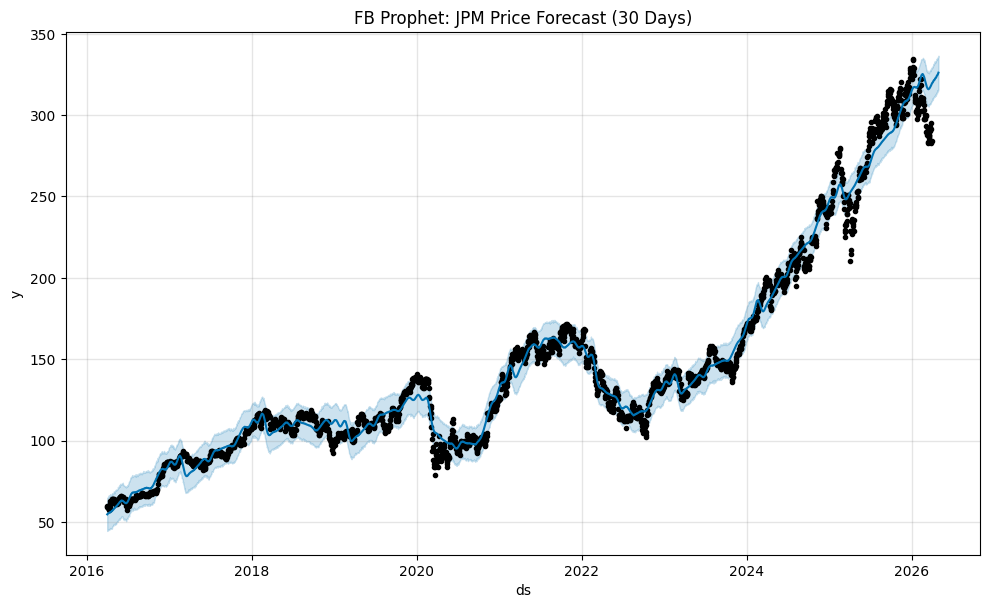

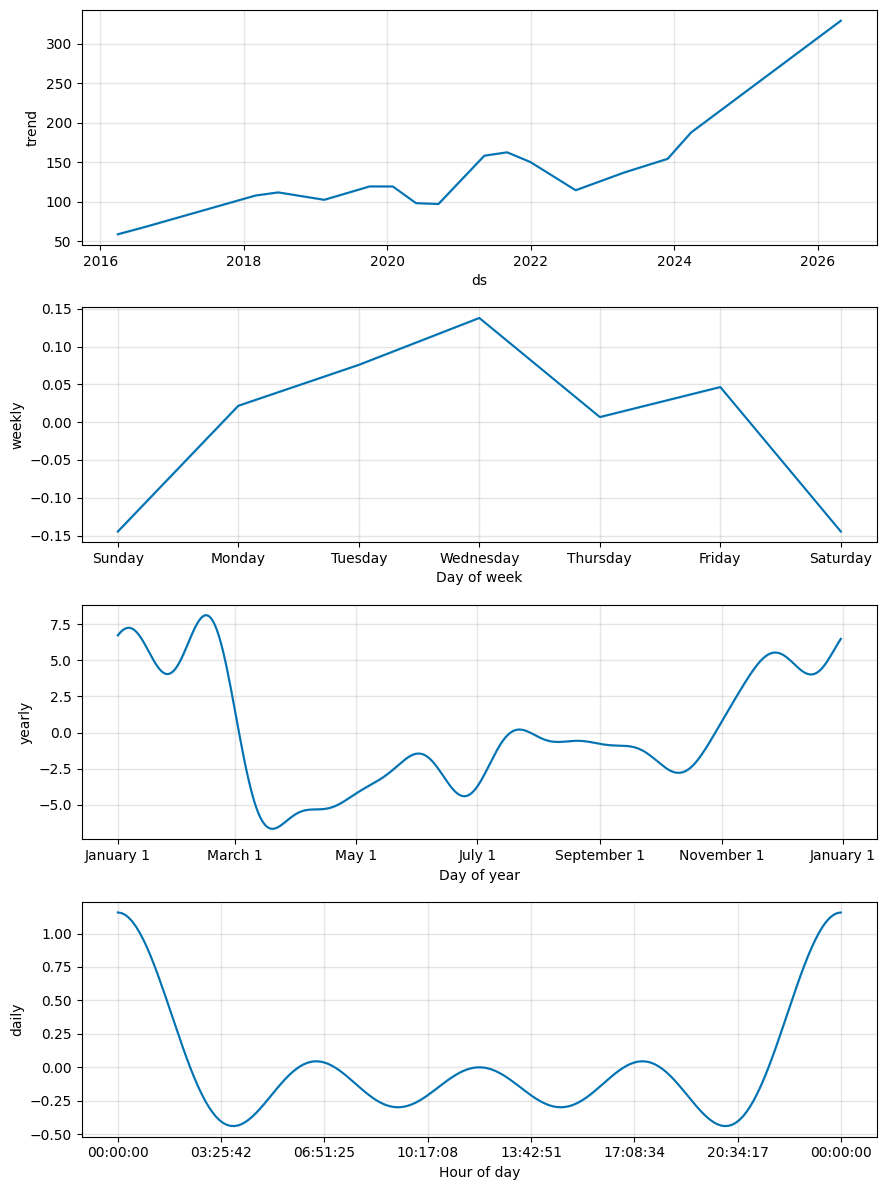

In [ ]:
# 1. Prepare data (Prophet requires specific column names: 'ds' and 'y')
df_prophet = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

# 2. Initialize and fit the model [Requirement C.3]
model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
model.fit(df_prophet)

# 3. Create a future dataframe for the next 30 days
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# 4. Plot the Forecast trend
fig1 = model.plot(forecast)
plt.title('FB Prophet: JPM Price Forecast (30 Days)')
plt.show()

# 5. Plot the Components (Trend, Weekly, Yearly seasonality)
fig2 = model.plot_components(forecast)
plt.show()

In [31]:
recommendation = "BUY"

summary = {
    "Growth Rate": "11.35%",
    "Expected Return (CAPM)": "15.60%",
    "Intrinsic Value": 338.60,
    "Market Price": 283.77,
    "Upside Potential": "19%",
    "Risk Level": "Moderate"
}

print("Investment Recommendation:", recommendation)
print("\nKey Metrics:")
for k, v in summary.items():
    print(f"{k}: {v}")

Investment Recommendation: BUY

Key Metrics:
Growth Rate: 11.35%
Expected Return (CAPM): 15.60%
Intrinsic Value: 338.6
Market Price: 283.77
Upside Potential: 19%
Risk Level: Moderate


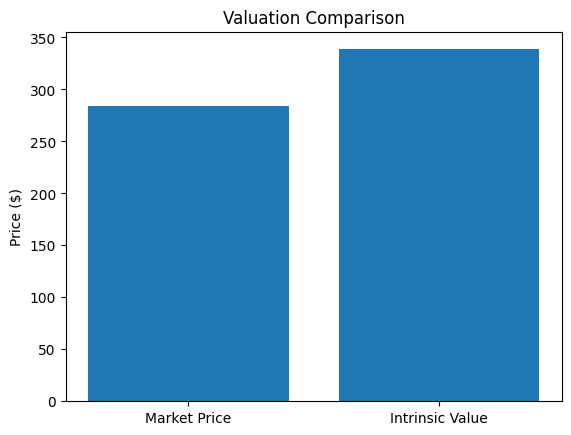

In [32]:
import matplotlib.pyplot as plt

labels = ['Market Price', 'Intrinsic Value']
values = [283.77, 338.60]

plt.bar(labels, values)
plt.title("Valuation Comparison")
plt.ylabel("Price ($)")
plt.show()

# Trade Signal Based on 20 and 50 SMA

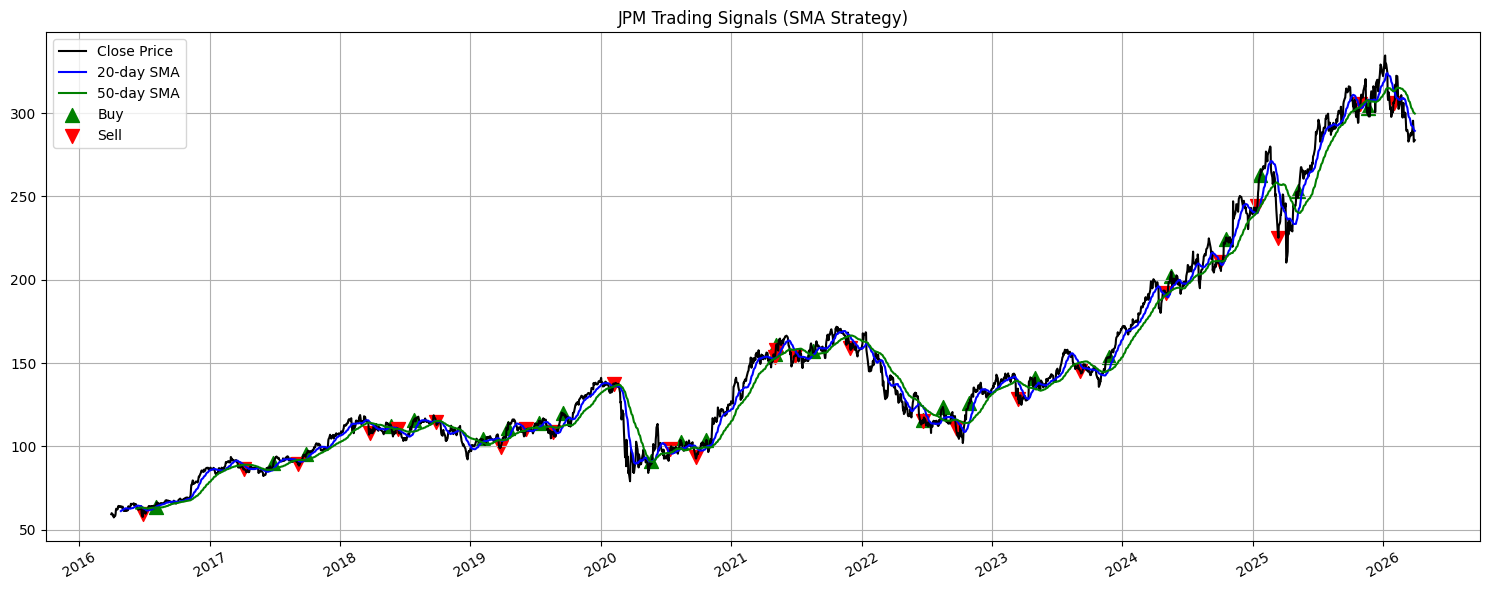

In [ ]:

jpm = df[['Date', 'Close']].copy()
jpm.columns = ['Date', 'JPM_Close']

jpm['Date'] = pd.to_datetime(jpm['Date'])
jpm['JPM_Close'] = pd.to_numeric(jpm['JPM_Close'], errors='coerce')

jpm = jpm.dropna().sort_values('Date').reset_index(drop=True)

jpm['SMA_20'] = jpm['JPM_Close'].rolling(20).mean()
jpm['SMA_50'] = jpm['JPM_Close'].rolling(50).mean()

jpm['Signal'] = 0
jpm.loc[jpm['SMA_20'] > jpm['SMA_50'], 'Signal'] = 1
jpm.loc[jpm['SMA_20'] < jpm['SMA_50'], 'Signal'] = -1

jpm['Position'] = jpm['Signal'].diff()

buy_signals = jpm[jpm['Position'] == 2]
sell_signals = jpm[jpm['Position'] == -2]

# Plot
plt.figure(figsize=(15, 6))
plt.plot(jpm['Date'], jpm['JPM_Close'], label='Close Price', color='black')
plt.plot(jpm['Date'], jpm['SMA_20'], label='20-day SMA', color='blue')
plt.plot(jpm['Date'], jpm['SMA_50'], label='50-day SMA', color='green')

plt.scatter(buy_signals['Date'], buy_signals['JPM_Close'], marker='^', color='green', s=100, label='Buy')
plt.scatter(sell_signals['Date'], sell_signals['JPM_Close'], marker='v', color='red', s=100, label='Sell')

plt.title('JPM Trading Signals (SMA Strategy)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()